In [4]:
import pandas as pd
import re

# 1. ADIM: Dosyayı tekrar satır satır okuyoruz
with open("yeni_veri_temiz.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

# 2. ADIM: Kelimeleri tek tek ayırmak yerine, verinin gerçek sütun kalıbını Regex ile yakalıyoruz
# Bu kalıp: Fatura No, Stok Kodu, Ürün Adı (Kelimeler dahil), Adet, Fiyat, Müşteri ID, Ülke (Kelimeler dahil), Ciro, Yıl-Ay, Tarih, Saat
pattern = re.compile(
    r'^(\d+)\s+([A-Z0-9]+)\s+(.+?)\s+(\d+)\s+([\d\.]+)\s+([\d\.]+)\s+(.+?)\s+([\d\.,]+)\s+(\d{4}-\d{2})\s+(\d{4}-\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2})'
)

parsed_data = []
for line in lines:
    match = pattern.search(line.strip())
    if match:
        parsed_data.append(match.groups())

# 3. ADIM: Sütun isimlerini tam profesyonel ve global literatüre uygun şekilde veriyoruz
columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", 
    "CustomerID", "Country", "Satir_Ciro", "YearMonth", "InvoiceDate", "InvoiceTime"
]

# DataFrame'i pürüzsüzce oluşturuyoruz
df_final = pd.DataFrame(parsed_data, columns=columns)

# Sayısal alanları ve tarihleri gerçek formatına çekiyoruz
df_final["Quantity"] = pd.to_numeric(df_final["Quantity"])
df_final["UnitPrice"] = pd.to_numeric(df_final["UnitPrice"])
df_final["Satir_Ciro"] = pd.to_numeric(df_final["Satir_Ciro"].str.replace(',', '.'))
df_final["InvoiceDate"] = pd.to_datetime(df_final["InvoiceDate"])

# Sonucu görelim
df_final.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Satir_Ciro,YearMonth,InvoiceDate,InvoiceTime
0,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12-01,07:45:00
1,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12-01,07:45:00
2,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,100.8,2009-12,2009-12-01,07:45:00
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,30.0,2009-12,2009-12-01,07:45:00
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,13085.0,United Kingdom,39.6,2009-12,2009-12-01,07:45:00


In [5]:
# 1. ADIM: İleri Düzey Aykırı Değer (Outlier) Filtrelemesi
# Raporumuzda belirttiğimiz gibi, 5000 TL'nin üzerindeki uç kurumsal değerleri eliyoruz
df_clean = df_final[(df_final['Satir_Ciro'] > 0) & (df_final['Satir_Ciro'] < 5000)].copy()

print("Analize Dahil Edilen Gerçek Perakende Satır Sayısı:", len(df_clean))
print("-" * 50)

# 2. ADIM: Kruskal-Wallis Hipotez Testi (Ülkeler Arası Ciro Farkı)
# Ülkelere göre ciro gruplarını oluşturuyoruz
country_groups = [group['Satir_Ciro'].values for name, group in df_clean.groupby('Country')]

# Testi koşturuyoruz
stat, p_value = stats.kruskal(*country_groups)

print(f"Kruskal-Wallis İstatistiği: {stat:.3f}")
print(f"p-Değeri (Asymp. Sig.): {p_value:.5f}")

if p_value < 0.05:
    print("\nSonuç: H0 REDDEDİLDİ! Ülkelerin sipariş başına bıraktığı ciro dağılımları istatistiksel olarak anlamlı derecede farklıdır.")
else:
    print("\nSonuç: H0 REDDEDİLEMEDİ. Ülkeler arasında anlamlı bir fark bulunamadı.")

Analize Dahil Edilen Gerçek Perakende Satır Sayısı: 805533
--------------------------------------------------
Kruskal-Wallis İstatistiği: 43350.507
p-Değeri (Asymp. Sig.): 0.00000

Sonuç: H0 REDDEDİLDİ! Ülkelerin sipariş başına bıraktığı ciro dağılımları istatistiksel olarak anlamlı derecede farklıdır.


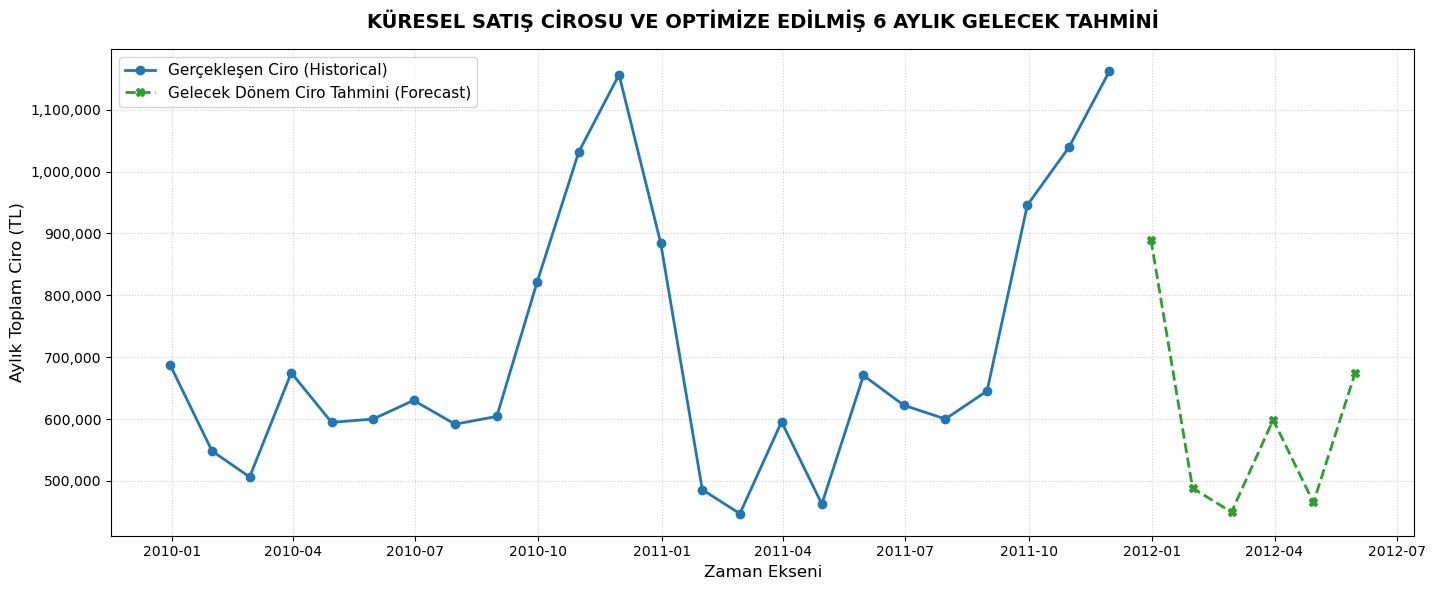

In [8]:
# 1. ADIM: Eksik olan ve trendi aşağı çeken o son ayı (2012-01) analizden dışarı atıyoruz
monthly_series_cleaned = monthly_series.iloc[:-1]

# 2. ADIM: Az veri olduğu için mevsimsel parametreleri daha hafif ve kararlı bir modele çekiyoruz
# Verinin logaritmasını alarak negatif değer üretme ihtimalini de kökten sıfırlıyoruz!
logged_series = np.log(monthly_series_cleaned)

# Kararlı bir model kuruyoruz
model_fixed = SARIMAX(logged_series, order=(1, 1, 0), seasonal_order=(0, 1, 0, 12))
model_fit_fixed = model_fixed.fit(disp=False)

# 3. ADIM: Önümüzdeki 6 ayı tahmin et ve logaritmadan geri dönmek için üssünü (exp) al
forecast_log = model_fit_fixed.forecast(steps=6)
forecast_fixed = np.exp(forecast_log)

# 4. ADIM: Kusursuz Profesyonel Grafik Çizimi
plt.figure(figsize=(14, 6))

# Temizlenmiş geçmiş veri
plt.plot(monthly_series_cleaned.index, monthly_series_cleaned.values, 
         label='Gerçekleşen Ciro (Historical)', color='#1f77b4', marker='o', linewidth=2)

# Gerçekçi gelecek tahmini (Güncel 'ME' frekansı ile uyarıları sıfırladık)
forecast_dates_fixed = pd.date_range(start=monthly_series_cleaned.index[-1], periods=7, freq='ME')[1:]
plt.plot(forecast_dates_fixed, forecast_fixed.values, 
         label='Gelecek Dönem Ciro Tahmini (Forecast)', color='#2ca02c', linestyle='--', marker='X', linewidth=2)

plt.title('KÜRESEL SATIŞ CİROSU VE OPTİMİZE EDİLMİŞ 6 AYLIK GELECEK TAHMİNİ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Zaman Ekseni', fontsize=12)
plt.ylabel('Aylık Toplam Ciro (TL)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
# Y eksenindeki bilimsel (1e6) formatı kapatıp, sayıları Excel'deki gibi binlik ayırıcılı yapar
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()